In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

In [45]:
#https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html

In [4]:
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

2024-12-01 18:56:01.048337: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


<h1> Define State , Rewards, Actions

In [3]:
class DynamicPricingEnv(gym.Env):
    def __init__(self):
        super(DynamicPricingEnv, self).__init__()
        
        # Define state: [remaining_inventory, competitor_price, demand_factor]
        self.observation_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)
        
        # Define action: price levels (discrete prices: $5, $10, $15)
        self.action_space = spaces.Discrete(3)
        
        # Inventory and demand parameters
        self.total_inventory = 100
        self.remaining_inventory = self.total_inventory
        self.demand_factor = np.random.uniform(0.5, 1.5)  # Fluctuating demand
        self.competitor_price = np.random.uniform(5, 15)  # Simulated competitor price

    def step(self, action):
        # Convert action to price
        price = [5, 10, 15][action]
        
        # Simulate demand
        demand = self.demand_factor * (15 - price + np.random.uniform(-1, 1))
        units_sold = min(demand, self.remaining_inventory)
        
        # Calculate revenue
        revenue = units_sold * price
        
        # Encourage revenue maximization but discourage inventory leftovers
        # Adjust to reward both revenue and minimize unsold inventory
        
        
        if self.remaining_inventory == 0:
            reward += 100  # Bonus for selling all inventory

        
        reward = revenue - 0.1 * self.remaining_inventory  # Penalty for excess inventory


        
        # Update inventory
        self.remaining_inventory -= units_sold
        
        # Create next state
        self.demand_factor = np.random.uniform(0.5, 1.5)
        self.competitor_price = np.random.uniform(5, 15)
        state = np.array([
            self.remaining_inventory / self.total_inventory,
            self.competitor_price / 15,
            self.demand_factor / 1.5,
        ], dtype=np.float32)  # Cast to float32
        
        print(state)
        
        # Check if the episode is done
        terminated = self.remaining_inventory <= 0  # True if inventory is depleted
        truncated = False  # No external truncation logic applied here

        # Return the step output as required
        return state, revenue, terminated, truncated, {}

    def reset(self, seed=None, options=None):
        self.remaining_inventory = self.total_inventory
        self.demand_factor = np.random.uniform(0.5, 1.5)
        self.competitor_price = np.random.uniform(5, 15)
        return np.array([
            self.remaining_inventory / self.total_inventory,
            self.competitor_price / 15,
            self.demand_factor / 1.5,
        ], dtype=np.float32), {}

<h1> training

In [37]:
# Initialize the environment
env = DynamicPricingEnv()

# Check the environment
check_env(env)

# Train the model
model = DQN(
    "MlpPolicy", env, verbose=1,
    exploration_fraction=0.3,  # 30% of the timesteps for exploration
    exploration_initial_eps=1.0,  # Fully random at the start
    exploration_final_eps=0.05    # Gradually reduce exploration to 5%
)
model.learn(total_timesteps=20000)


[0.87689734 0.65505946 0.64013344]
[0.95697534 0.84198195 0.72660094]
[0.9098232  0.45076162 0.45060077]
[0.87046283 0.36062372 0.6846355 ]
[0.77552825 0.8509792  0.44647515]
[0.7423495  0.62580967 0.3969553 ]
[0.7432298  0.82486624 0.5481282 ]
[0.7508055 0.4761364 0.6656888]
[0.7601549 0.6858198 0.8061182]
[0.6440795  0.87982154 0.6410816 ]
[0.5437187  0.37869713 0.50662047]
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[0.9974431 0.9744592 0.9380708]
[0.9889107  0.90889764 0.77204293]
[0.99099874 0.60702777 0.82383955]
[0.8554974  0.48627016 0.7260268 ]
[0.85638374 0.83954173 0.8993177 ]
[0.8637641  0.73560727 0.42512578]
[0.8025169  0.65229917 0.5562747 ]
[0.8046424  0.7163658  0.65364355]
[0.6986084  0.77615386 0.67957497]
[0.6547451  0.51560694 0.6780332 ]
[0.55770123 0.40214178 0.71012235]
[0.44961455 0.75696    0.8679497 ]
[0.32340813 0.44151753 0.3882412 ]
[0.29614073 0.38117254 0.669234  ]
[0.29314592 0.8136454  0.8217587 ]
[0.17

[0.7609041  0.5757999  0.42684764]
[0.70039207 0.8587476  0.52198124]
[0.61838275 0.73041314 0.66601735]
[0.6135914  0.40665925 0.82368803]
[0.60444164 0.5384736  0.8417908 ]
[0.5938828  0.73768765 0.8118968 ]
[0.589729   0.59342986 0.7091297 ]
[0.538737   0.45908797 0.9630544 ]
[0.3829534  0.90862525 0.5942644 ]
[0.38386157 0.6214257  0.3660123 ]
[0.35504282 0.3644624  0.96398205]
[0.34321    0.66371274 0.5925351 ]
[0.30477548 0.58140665 0.8299213 ]
[0.24576132 0.5391386  0.42919233]
[0.21590078 0.35664573 0.4014497 ]
[0.22127774 0.36277083 0.36277172]
[0.22392894 0.7240426  0.87948924]
[0.16111815 0.47711188 0.36716017]
[0.1651293 0.4918615 0.5257735]
[0.15987244 0.95295095 0.38976598]
[0.12847309 0.8553654  0.61869204]
[0.11947162 0.4369602  0.72520834]
[0.00556197 0.62581134 0.59793335]
[0.         0.8894018  0.50870657]
[0.9426902  0.8894298  0.60558236]
[0.89366555 0.37472343 0.5317299 ]
[0.8510905  0.34676275 0.46336174]
[0.78415376 0.34134877 0.7551526 ]
[0.7941225 0.5921693 0.

[0.9190775  0.5270166  0.40029418]
[0.8867182  0.48095798 0.82970953]
[0.8184014  0.5971522  0.60140157]
[0.72858363 0.36720684 0.6657574 ]
[0.7333679  0.89848894 0.34081277]
[0.6859369  0.70397735 0.83136827]
[0.55813    0.69565237 0.58460975]
[0.5169193  0.62120396 0.64992404]
[0.5072426 0.5777957 0.8400102]
[0.44165045 0.35705474 0.8671601 ]
[0.31025022 0.33919322 0.9753318 ]
[0.32202888 0.5505409  0.4063752 ]
[0.31773037 0.6125348  0.6589761 ]
[0.21583723 0.7935646  0.8656594 ]
[0.08970714 0.39396074 0.58530575]
[0.         0.39971423 0.6035813 ]
[0.9620687  0.68438953 0.68459743]
[0.9131987 0.5879665 0.5942197]
[0.8185932 0.8758714 0.6027494]
[0.81793576 0.93441147 0.9008465 ]
[0.81568176 0.8859824  0.8539098 ]
[0.69356066 0.779896   0.7585524 ]
[0.6474447 0.3360117 0.670021 ]
[0.54196894 0.43317991 0.6582111 ]
[0.50143003 0.91328496 0.65528065]
[0.44256923 0.4127909  0.60343325]
[0.43670413 0.88988155 0.62580746]
[0.33765027 0.80846846 0.9885877 ]
[0.3502124  0.9129437  0.5372768

[0.3581795  0.626121   0.38251656]
[0.33467433 0.79378694 0.7443353 ]
[0.23217523 0.78697854 0.86393195]
[0.23610708 0.33848253 0.57309896]
[0.19559605 0.47545508 0.82958144]
[0.07506004 0.6211568  0.5343204 ]
[0.         0.99897534 0.5151479 ]
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20       |
|    ep_rew_mean      | 654      |
|    exploration_rate | 0.899    |
| time/               |          |
|    episodes         | 32       |
|    fps              | 401      |
|    time_elapsed     | 1        |
|    total_timesteps  | 639      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 37.9     |
|    n_updates        | 134      |
----------------------------------
[0.95935947 0.4515185  0.50714636]
[0.9137484  0.92963624 0.45803946]
[0.8476546  0.60197246 0.7388819 ]
[0.7440784  0.40854803 0.7217677 ]
[0.74564123 0.75594085 0.8418674 ]
[0.6294061 0.674901  0.7516626]
[0.63848984 0.63894004 

[0.62232494 0.9345281  0.9758851 ]
[0.47515616 0.99621385 0.93496406]
[0.40171787 0.62944674 0.7446668 ]
[0.33824533 0.6020887  0.92512935]
[0.19735995 0.6897887  0.8690865 ]
[0.07029556 0.48526385 0.82687455]
[0.061246   0.43743613 0.51123184]
[0.         0.73239315 0.432475  ]
[0.9430921  0.34659347 0.9071889 ]
[0.8622418  0.4371659  0.83006626]
[0.80417466 0.45292267 0.9958821 ]
[0.6639587  0.92280287 0.6725081 ]
[0.5661739  0.8560105  0.42303243]
[0.570614   0.5515666  0.58919835]
[0.5336602  0.40726787 0.34307507]
[0.5072369  0.84179276 0.86131877]
[0.38967988 0.97180855 0.45868707]
[0.360991   0.78985757 0.8410303 ]
[0.35353762 0.37024155 0.47508097]
[0.31491023 0.738186   0.7832513 ]
[0.3038099 0.5422067 0.8261921]
[0.19178393 0.4168941  0.6259139 ]
[0.14363962 0.41847897 0.9852138 ]
[0.        0.5162661 0.5493367]
[0.92396367 0.4259036  0.80207163]
[0.7977182  0.7518797  0.37512082]
[0.7437603  0.8656695  0.68683565]
[0.64752513 0.94792366 0.6882758 ]
[0.54729056 0.65781456 0.6

...

[0.94981843 0.5124331  0.9898447 ]
[0.8722518  0.50873244 0.7296723 ]
[0.81166995 0.61988163 0.7284509 ]
[0.765245   0.35793114 0.77884597]
[0.7131283  0.6151174  0.35605496]
[0.68744934 0.6155779  0.6354359 ]
[0.63943654 0.880568   0.69118434]
[0.5978464  0.33440295 0.80933267]
[0.5411    0.7865526 0.7256493]
[0.47588575 0.9703031  0.4483382 ]
[0.4384966  0.42101845 0.7728271 ]
[0.38398317 0.6680533  0.4179756 ]
[0.35488883 0.64947224 0.51111615]
[0.32126355 0.79238707 0.90681446]
[0.2611792  0.58176535 0.4827042 ]
[0.23102379 0.91250867 0.43000358]
[0.1980189  0.6838686  0.59307194]
[0.14693974 0.35943565 0.7828973 ]
[0.09451605 0.7919958  0.66306645]
[0.04337037 0.7092879  0.8331405 ]
[0.         0.36052728 0.956816  ]
[0.9334348 0.8116808 0.67133  ]
[0.89082843 0.58951366 0.76075095]
[0.82568514 0.9887895  0.86056066]
[0.77371347 0.8877139  0.7852206 ]
[0.71244866 0.37836182 0.90323025]
[0.64567655 0.38432205 0.97395295]
[0.5681606  0.7239904  0.47298694]
[0.5264904  0.35607383 0.4

[0.83843833 0.34348467 0.61184   ]
[0.7898922 0.5676273 0.7906899]
[0.72088885 0.6968305  0.4801178 ]
[0.6776862 0.7438773 0.7116601]
[0.6275044  0.52365035 0.89058805]
[0.57391506 0.96405905 0.5069968 ]
[0.5284023  0.9413151  0.61093277]
[0.47685808 0.43558484 0.7643621 ]
[0.41656613 0.38207152 0.41350892]
[0.38168475 0.47527504 0.8549838 ]
[0.3252647 0.6054441 0.9665703]
[0.2649726  0.85064274 0.531329  ]
[0.22547567 0.5052829  0.85158604]
[0.15223382 0.37347037 0.8556232 ]
[0.07813494 0.6129027  0.59633225]
[0.03429485 0.984955   0.40477103]
[0.00419616 0.44803834 0.6706704 ]
[0.        0.780518  0.4952032]
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.2     |
|    ep_rew_mean      | 984      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1400     |
|    fps              | 234      |
|    time_elapsed     | 82       |
|    total_timesteps  | 19218    |
| train/              |         

[0.96038544 0.49538583 0.6878657 ]
[0.916475  0.7397886 0.9527173]
[0.8584656  0.6072889  0.83715975]
[0.7935075  0.96819925 0.73724216]
[0.7448046 0.4557442 0.5888106]
[0.6919167  0.78278047 0.5053929 ]
[0.65082055 0.68781006 0.38138488]
[0.6243585  0.35105458 0.34414497]
[0.5968796  0.8763893  0.47782797]
[0.560819   0.49097052 0.71231765]
[0.5115175  0.46500072 0.4764264 ]
[0.48106587 0.5433398  0.42690307]
[0.45089224 0.9033071  0.75836486]
[0.3827262  0.34449944 0.86243355]
[0.3096056  0.94725573 0.9360394 ]
[0.16554977 0.6630871  0.611936  ]
[0.12200774 0.8625643  0.41634545]
[0.09323347 0.912967   0.87915987]
[0.02747765 0.5898921  0.5027477 ]
[0.         0.80336595 0.7722415 ]
[0.9896293 0.342369  0.7916791]
[0.93118954 0.6926584  0.5397572 ]
[0.88292    0.51485664 0.5310043 ]
[0.8448363  0.92525065 0.98153836]
[0.76979846 0.78168136 0.33547968]
[0.7492067 0.9022022 0.6408843]
[0.6916515  0.74921846 0.7460572 ]
[0.6253581  0.38206866 0.9520173 ]
[0.56574976 0.49002013 0.97563  

[0.29166386 0.9506039  0.99856853]
[0.21797992 0.5373964  0.8264081 ]
[0.14701034 0.8804365  0.4775816 ]
[0.11238386 0.5154413  0.95008063]
[0.0423243  0.6987561  0.45047042]
[0.01285865 0.5516801  0.62039995]
[0.         0.81292284 0.54120696]
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.4     |
|    ep_rew_mean      | 988      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1420     |
|    fps              | 230      |
|    time_elapsed     | 85       |
|    total_timesteps  | 19624    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 15.4     |
|    n_updates        | 4880     |
----------------------------------
[0.95504814 0.42099592 0.46663243]
[0.91905534 0.7740486  0.37496763]
[0.89158964 0.7392742  0.5329105 ]
[0.85283095 0.44588238 0.75259745]
[0.80738145 0.39445126 0.8685363 ]
[0.7467323  0.89515495 0.9015813 ]
[0.68996567 0.394104

[0.39623433 0.34639776 0.39321658]
[0.36360484 0.93341947 0.9611825 ]
[0.28642642 0.9020623  0.936472  ]
[0.20698085 0.56183356 0.8007289 ]
[0.14513671 0.8934265  0.66341674]
[0.08746707 0.70955193 0.45998573]
[0.05425382 0.40003756 0.41014257]
[0.02431138 0.8359537  0.38666964]
[0.         0.76909894 0.4224346 ]
[0.92980665 0.63863295 0.78829545]
[0.8699927  0.77133656 0.6562474 ]
[0.81706303 0.8731639  0.85192764]
[0.7535927  0.48939943 0.40674633]
[0.7176985  0.5139598  0.51220524]
[0.6785465 0.3353227 0.9947516]
[0.6073846 0.5578407 0.9418272]
[0.53747714 0.3450352  0.8681094 ]
[0.48321542 0.4507453  0.7672561 ]
[0.37557173 0.34283185 0.7957086 ]
[0.3040525  0.82727396 0.96085805]
[0.24132638 0.82053816 0.57215434]
[0.20522636 0.75243    0.59085786]
[0.15236145 0.83341545 0.7028453 ]
[0.10435241 0.81395674 0.59200317]
[0.05588061 0.6440291  0.9596241 ]
[0.         0.6760805  0.98711777]
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20

<h1> evaluations

In [38]:
from stable_baselines3.common.evaluation import evaluate_policy
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10)
#print(f"Mean Reward: {mean_reward}, Std Reward: {std_reward}")


[0.956856   0.8922622  0.49516612]
[0.9200176  0.4144044  0.74004877]
[0.86305493 0.9268675  0.36818406]
[0.8318197 0.5002304 0.7928611]
[0.76767415 0.9394699  0.9197584 ]
[0.7066759  0.41313052 0.8506911 ]
[0.6521395  0.5484486  0.98040336]
[0.57535386 0.6134713  0.5030187 ]
[0.5392748  0.70559317 0.5137097 ]
[0.49643663 0.36423454 0.37631276]
[0.46538424 0.6051133  0.4501881 ]
[0.43826514 0.8250325  0.5442582 ]
[0.39844123 0.5699085  0.40668112]
[0.3624898  0.94432545 0.73728734]
[0.31424254 0.8863688  0.9766785 ]
[0.24350585 0.6985073  0.882927  ]
[0.17423344 0.9085356  0.8521385 ]
[0.11140835 0.6553576  0.4279924 ]
[0.07590084 0.67718256 0.56371135]
[0.03670535 0.67343646 0.4134329 ]
[0.00957664 0.5230126  0.6610662 ]
[0.        0.9345724 0.5431548]
[0.9400649  0.88028085 0.72274685]
[0.87638175 0.53424776 0.36248538]
[0.844065   0.612691   0.41164315]
[0.8142731  0.5099294  0.34165695]
[0.79095185 0.5745844  0.580633  ]
[0.75296485 0.7918653  0.3801873 ]
[0.72233063 0.83306366 0.7

In [39]:
mean_reward,std_reward

(1000.0000002384186, 5.44200525785128e-06)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN  # Replace with your model (e.g., PPO, A2C)
from stable_baselines3.common.env_util import make_vec_env  # For VecEnv
from stable_baselines3.common.vec_env import DummyVecEnv 

In [41]:
# Initialize the environment
env = DynamicPricingEnv()  # Replace with your environment
env = DummyVecEnv([lambda: env])  # Wrap it in DummyVecEnv to ensure compatibility

In [42]:


# Function to evaluate the model and collect episode rewards
def evaluate_and_plot(model, env, n_eval_episodes=100):
    episode_rewards = []  # Store total rewards for each episode

    for episode in range(n_eval_episodes):
        obs = env.reset()  # VecEnv API (no need for unpacking)
        done = False
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)  # Predict action
            obs, reward, done, _ = env.step(action)  # Take action
            total_reward += reward

        episode_rewards.append(total_reward)
    return episode_rewards

# Call the evaluation and plotting function
episode_rewards= evaluate_and_plot(model, env, n_eval_episodes=100)

[0.94186586 0.63178706 0.4063992 ]
[0.9118669  0.9126593  0.49346727]
[0.8714267  0.59344083 0.7585471 ]
[0.82097775 0.85294944 0.6207182 ]
[0.76539916 0.64592594 0.84165645]
[0.6983556  0.43999347 0.63384306]
[0.6527109  0.6499717  0.33923975]
[0.6270476  0.44781372 0.68602145]
[0.569328  0.5034301 0.8022118]
[0.50703984 0.5541902  0.5183572 ]
[0.4759309  0.86051553 0.6191583 ]
[0.42052776 0.76138145 0.66846865]
[0.37460962 0.7634284  0.7555739 ]
[0.31229863 0.86301357 0.8427678 ]
[0.24284826 0.52904904 0.7319897 ]
[0.19377482 0.5284256  0.8298969 ]
[0.12993705 0.5615764  0.41863552]
[0.09433112 0.9840032  0.9334955 ]
[0.0141265  0.79118943 0.42390054]
[0.        0.9366264 0.3773925]
[0.9633244  0.8166886  0.42191413]
[0.926099  0.9537588 0.4841607]
[0.8949798  0.5683859  0.45867333]
[0.8567252 0.8098413 0.8645195]
[0.7864866 0.5102129 0.3490335]
[0.75782347 0.88444525 0.55886596]
[0.7130339 0.6367341 0.4778265]
[0.6793394  0.93807715 0.8264584 ]
[0.6091564 0.8902274 0.8805839]
[0.554

[0.49576387 0.38188577 0.46705428]
[0.4641112  0.6974841  0.39225507]
[0.4368291  0.6941298  0.57544035]
[0.38942286 0.5767034  0.8747487 ]
[0.31078312 0.9179618  0.9388824 ]
[0.24827015 0.4140358  0.7910329 ]
[0.19240661 0.59076    0.41037145]
[0.15607597 0.7569629  0.59993976]
[0.11384191 0.7630392  0.59050584]
[0.076898   0.5349777  0.50214094]
[0.03409925 0.8681868  0.504176  ]
[0.         0.8556683  0.46604332]
[0.94261146 0.96242535 0.39451823]
[0.9099369  0.5525426  0.37717023]
[0.8872108  0.38187373 0.72831863]
[0.8296265 0.9864001 0.7114481]
[0.7830851  0.8408076  0.50911516]
[0.73892206 0.34358507 0.78623223]
[0.68413   0.5254775 0.3606018]
[0.65370077 0.6988854  0.6737625 ]
[0.59939355 0.6751904  0.45757276]
[0.56066096 0.40398484 0.5517529 ]
[0.5168419  0.71200067 0.693963  ]
[0.4704321 0.8836361 0.4534628]
[0.4426138  0.92300737 0.47306114]
[0.41412657 0.60404813 0.3812794 ]
[0.38235304 0.66143095 0.8725569 ]
[0.3079587 0.5183696 0.4544868]
[0.28015104 0.4092748  0.6398941

[0.2995435  0.51200277 0.7739208 ]
[0.24107645 0.7045843  0.9185189 ]
[0.18353038 0.70510525 0.88428587]
[0.13004169 0.5413553  0.6574016 ]
[0.082634  0.4515145 0.9286694]
[0.01053166 0.82473844 0.61933917]
[0.        0.8792082 0.4779994]
[0.93321353 0.38493243 0.8065124 ]
[0.86105084 0.53872985 0.92286956]
[0.80123645 0.49114862 0.8032371 ]
[0.751897   0.7383943  0.49517474]
[0.71004087 0.50579935 0.9476181 ]
[0.6487685 0.7387373 0.5738608]
[0.6001467 0.6905724 0.6139282]
[0.5567949  0.97477424 0.9376997 ]
[0.4729467 0.972163  0.8553844]
[0.40354285 0.43177897 0.9261337 ]
[0.33590072 0.35508174 0.569825  ]
[0.28871605 0.9736135  0.82984555]
[0.22548446 0.8142276  0.87958443]
[0.14886412 0.6782352  0.71022534]
[0.09481181 0.68762445 0.5859929 ]
[0.0520718 0.9719381 0.5928307]
[0.01635668 0.7497452  0.39272973]
[0.         0.47470528 0.72772896]
[0.9749701  0.7127966  0.67681676]
[0.92708325 0.92349166 0.5073471 ]
[0.8854079  0.9701975  0.67993075]
[0.8428683  0.6073258  0.51214993]
[0.

[0.24801086 0.6837365  0.5974305 ]
[0.20094518 0.73092246 0.6152849 ]
[0.15699725 0.738214   0.5590254 ]
[0.11359508 0.59115356 0.70961803]
[0.05294929 0.6801685  0.62613034]
[0.01485146 0.629318   0.9215838 ]
[0.        0.8265984 0.9386804]
[0.97301495 0.52299404 0.89227897]
[0.9042792  0.85178113 0.48791188]
[0.86669934 0.8592327  0.93684137]
[0.7978376  0.36931798 0.7623145 ]
[0.7458054 0.7504571 0.6403687]
[0.6953625 0.9771462 0.5853113]
[0.6471163  0.76259464 0.3346932 ]
[0.6260738  0.5698773  0.59387636]
[0.5833013  0.33783454 0.591341  ]
[0.53820705 0.8315094  0.37177333]
[0.51180166 0.9756706  0.37863865]
[0.48895633 0.90724325 0.78870463]
[0.43106055 0.6171407  0.36186528]
[0.40631562 0.38910535 0.9135321 ]
[0.3400381  0.51380783 0.4309509 ]
[0.30238056 0.9573554  0.63219887]
[0.25848287 0.90064836 0.77465177]
[0.20464867 0.84397215 0.5633358 ]
[0.16634202 0.3865406  0.461074  ]
[0.13633347 0.5514603  0.7784674 ]
[0.08802332 0.44784752 0.61135876]
[0.04554277 0.78117216 0.8544

[0.7708961  0.84072906 0.9603993 ]
[0.6995678  0.73568743 0.6649267 ]
[0.6452788  0.4608259  0.52305967]
[0.6078398  0.7892706  0.46306664]
[0.5753934 0.945994  0.8191755]
[0.52013654 0.36531284 0.60428923]
[0.47348037 0.7057989  0.41031623]
[0.44174394 0.8524491  0.5892405 ]
[0.39791936 0.920382   0.39030448]
[0.37307328 0.49305665 0.43620118]
[0.33529693 0.37756765 0.3944577 ]
[0.3086109  0.35044226 0.78184   ]
[0.25713807 0.6193845  0.8417915 ]
[0.18956456 0.48443252 0.622029  ]
[0.14594802 0.50618875 0.921128  ]
[0.06359882 0.7420452  0.44600666]
[0.0306279  0.5614343  0.90221566]
[0.         0.5343973  0.51744604]
[0.94947743 0.4628557  0.35116938]
[0.92336845 0.46360555 0.3787634 ]
[0.8915442  0.46628767 0.7287461 ]
[0.84663445 0.49345407 0.8069015 ]
[0.7749508  0.71958506 0.4547519 ]
[0.7468182  0.94908017 0.9021454 ]
[0.68272233 0.79477686 0.88636076]
[0.60829467 0.929476   0.7958586 ]
[0.5582927  0.34965387 0.6263777 ]
[0.51919484 0.98249346 0.9803765 ]
[0.45760143 0.5921577  

[0.29041797 0.6944853  0.5914372 ]
[0.24007736 0.7956769  0.929613  ]
[0.18195826 0.5366581  0.99085873]
[0.10070913 0.51724315 0.41693714]
[0.06785323 0.47043785 0.85815954]
[0.00236364 0.72674066 0.6157981 ]
[0.         0.34624556 0.4313339 ]
[0.9442297  0.743818   0.52495974]
[0.8974126  0.91004735 0.65463215]
[0.84275645 0.553048   0.84000915]
[0.7788169  0.4550836  0.85513276]
[0.7224253  0.75783765 0.59597933]
[0.6777737  0.82267565 0.8735738 ]
[0.60348415 0.3762748  0.96199685]
[0.5254046  0.87051934 0.5489832 ]
[0.48272136 0.9225052  0.90024465]
[0.42078674 0.5080533  0.4031848 ]
[0.3882058  0.85142034 0.36543825]
[0.35666865 0.67577255 0.45100307]
[0.31735417 0.6932352  0.7041712 ]
[0.25865415 0.36253434 0.5095937 ]
[0.22294895 0.7506846  0.7043382 ]
[0.17380053 0.34459245 0.71518385]
[0.13015468 0.7719476  0.70830506]
[0.08635867 0.54238945 0.56724507]
[0.04654083 0.8239034  0.68114376]
[0.         0.5169645  0.77786994]
[0.941838   0.81619173 0.34914157]
[0.91048515 0.564628

[0.5733705  0.49617064 0.40788114]
[0.5463621  0.94519424 0.47959682]
[0.5159542  0.3912745  0.37313998]
[0.49102953 0.47979888 0.55057716]
[0.44368753 0.36939657 0.66706556]
[0.38967702 0.4160367  0.55582255]
[0.3516949 0.4046597 0.630388 ]
[0.30631003 0.9651523  0.33540335]
[0.28469163 0.82058215 0.87181854]
[0.21550179 0.44567412 0.5034819 ]
[0.18362194 0.77764153 0.9145721 ]
[0.10284752 0.8811023  0.43589354]
[0.06416844 0.598355   0.6169171 ]
[0.0107718  0.5078518  0.38399583]
[0.         0.38417265 0.5581671 ]
[0.9628714 0.7892977 0.6878197]
[0.9141239  0.38503397 0.94621146]
[0.83033663 0.6794761  0.74200547]
[0.7753556 0.9258751 0.8249682]
[0.72034353 0.7998461  0.7725143 ]
[0.66220725 0.8040613  0.534361  ]
[0.62737143 0.9829851  0.7169161 ]
[0.5770243  0.7912848  0.66009575]
[0.52381736 0.64351064 0.33702713]
[0.5033468 0.8468857 0.6779603]
[0.44659492 0.49027807 0.5938528 ]
[0.40234593 0.9595094  0.59574074]
[0.35565546 0.8752513  0.60153085]
[0.3026508  0.60002446 0.7201028

[0.8414308  0.46188137 0.41263705]
[0.8045808  0.49044383 0.62874883]
[0.7534177  0.40940747 0.71653557]
[0.6904353 0.8112539 0.8455986]
[0.62981313 0.9605497  0.39730346]
[0.5980702  0.4710857  0.98909193]
[0.526913   0.88077986 0.9516896 ]
[0.46059048 0.97700363 0.37447613]
[0.42965674 0.5050137  0.74570894]
[0.3778148  0.8972168  0.48699483]
[0.33764067 0.9073774  0.5848913 ]
[0.29124102 0.35814238 0.40449837]
[0.26227552 0.37338528 0.6076648 ]
[0.2149541 0.8648363 0.6466385]
[0.17450656 0.86469674 0.58220166]
[0.13732749 0.848314   0.70191807]
[0.07822198 0.7083937  0.78384525]
[0.00925706 0.87472314 0.9781927 ]
[0.         0.74782664 0.6130407 ]
[0.9527781 0.8998054 0.6322564]
[0.90777206 0.6427793  0.6473607 ]
[0.86164224 0.81734484 0.46568418]
[0.8219484  0.48372892 0.9118098 ]
[0.74953705 0.9535568  0.38592985]
[0.71893305 0.67092067 0.95235014]
[0.6551773 0.8485552 0.9601417]
[0.59208024 0.5186383  0.7171873 ]
[0.5375697 0.9989322 0.5032889]
[0.50259    0.91620547 0.37137833]


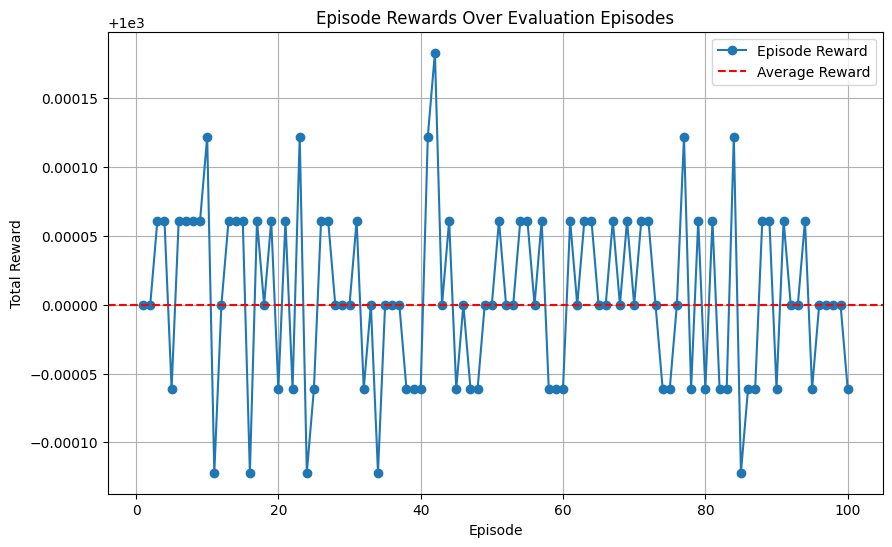

Average Reward: 1000.00
Max Reward: 1000.00
Min Reward: 1000.00


In [43]:
# Convert rewards to a numpy array for easier handling
episode_rewards = np.array(episode_rewards).flatten()

# Plot the rewards
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(episode_rewards) + 1), episode_rewards, marker="o", label="Episode Reward")
plt.axhline(y=np.mean(episode_rewards), color="r", linestyle="--", label="Average Reward")
plt.title("Episode Rewards Over Evaluation Episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.show()

# Print summary statistics
print(f"Average Reward: {np.mean(episode_rewards):.2f}")
print(f"Max Reward: {np.max(episode_rewards):.2f}")
print(f"Min Reward: {np.min(episode_rewards):.2f}")

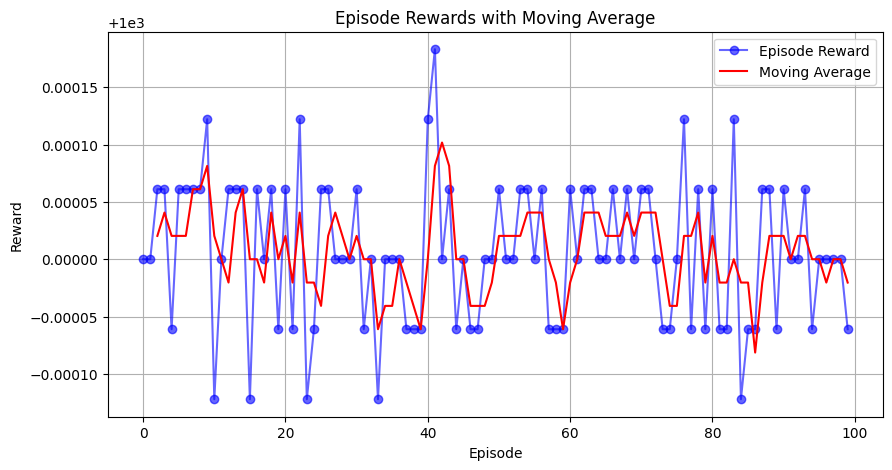

In [46]:
import numpy as np

# Compute moving average
window_size = 3  # Smoothing window size
moving_avg = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, marker='o', linestyle='-', color='b', alpha=0.6, label='Episode Reward')
plt.plot(range(window_size - 1, len(episode_rewards)), moving_avg, color='r', label='Moving Average')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Episode Rewards with Moving Average')
plt.legend()
plt.grid()
plt.show()


<h1> Predictions

In [12]:
# Save and load the trained model this is a zip file
model.save("dynamic_pricing_dqn_v1")

In [13]:
 # Load the trained model
dynamic_price_model = DQN.load("dynamic_pricing_dqn_v1")

In [14]:
# Test Input: Define a specific state
# Example: Remaining inventory = 50, Competitor price = 10, Demand factor = 1.2
test_state = np.array([
    50 / 100,  # Normalize remaining inventory by total inventory
    10 / 15,   # Normalize competitor price by maximum price
    1.2 / 1.5  # Normalize demand factor by its maximum value
], dtype=np.float32)

# Get the action (price level) predicted by the model
action, _ = model.predict(test_state)

# Map action to actual price (ensure alignment with training)
price_levels = [5, 10, 15]  # Same as in the environment
predicted_price = price_levels[action]

# Print the result
print(f"Predicted Action: {action}, Predicted Price: ${predicted_price}")

Predicted Action: 1, Predicted Price: $10


In [15]:
#predict using loaded model

In [16]:
# Get the action (price level) predicted by the model
action, _ = dynamic_price_model.predict(test_state)

# Map action to actual price (ensure alignment with training)
price_levels = [5, 10, 15]  # Same as in the environment
predicted_price = price_levels[action]

# Print the result
print(f"Predicted Action: {action}, Predicted Price: ${predicted_price}")

Predicted Action: 1, Predicted Price: $10
